In [1]:
import node2vec
import sys

print(f"Version détectée : {node2vec.__version__}")
print(f"Emplacement physique : {node2vec.__file__}")
print("-" * 30)
print("Ordre de priorité des dossiers (sys.path) :")
for path in sys.path:
    print(path)

Version détectée : 0.5.0
Emplacement physique : /Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/node2vec/__init__.py
------------------------------
Ordre de priorité des dossiers (sys.path) :
/Users/bgdu69/miniconda3/envs/stageM2/lib/python310.zip
/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10
/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/lib-dynload

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import json
import numpy as np
import shap

In [10]:
def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

G = load_graphml_safe("Airports.graphml")

## Import des shap values
shap_exp = gp.utils.loadsave_data_joblib(data=None, filepath = "shap_explainer.joblib", mode="load")

groupes = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Attributs": ['community_u', 'community_v', 'same_community', 'infomap_u', 'infomap_v', 'same_infomap']
}

group_indices = [
    [shap_exp.feature_names.index(f) for f in features_du_groupe]
    for features_du_groupe in groupes.values()
]

new_shap_values = np.array([
    shap_exp.values[:, indices].sum(axis=1) for indices in group_indices
]).T

new_exp = shap.Explanation(
    values=new_shap_values,
    base_values=shap_exp.base_values,
    data=None, # Les données brutes groupées (optionnel)
    feature_names=list(groupes.keys())
)

shap.plots.bar(new_exp)

print("ancienne explanation")
shap.plots.bar(shap_exp)

✅ Graphe chargé : 3363 nœuds et 13547 liens.


AttributeError: module 'src.SHAP_like_graph_tool.utils' has no attribute 'load_shap_analysis'

In [8]:
i=1
j=0

print("######################################")
print(f"#### graph sbm {i:.2f} pos {j:.2f} ####")
print("######################################")
G_name = f"artificial_graph_sbm_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{j:.2f}'.replace('.', '_')}"
print(G_name)
with open(f"graph_library/{G_name}.json", "r") as f:
    data = json.load(f)

G = nx.node_link_graph(data)

print(f"Graphe chargé : {len(G.nodes)} nœuds et {len(G.edges)} arêtes. \n")

gp.execute(G,G_name)

######################################
#### graph sbm 1.00 pos 0.00 ####
######################################
artificial_graph_sbm_1_00_pos_0_00
Graphe chargé : 1000 nœuds et 3500 arêtes. 

Validation du Graphe terminée. Lancement des calculs...
Graphe original: 3500 liens
Graphe d'entraînement: 2975 liens
Liens cachés pour le test: 525
Pré-calcul des métriques de nœuds...


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


DataFrame créé <3 : 7000 paires de noeuds choisies


--- Calcul des métriques de communauté ---
Calcul des communautés de louvain...
Calcul des communautés via Infomap...
Calcul des communautés via SBM...


--- Calcul des métriques de distance ---
Calcul de Node2Vec homophilie p=2, q=0.5 ...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2): 100%|██████████| 25/25 [00:03<00:00,  6.53it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Calcul de DeepWalk p=1, q=1 ...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 3): 100%|██████████| 25/25 [00:03<00:00,  6.46it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Dataset (DataFrame) sauvegardé : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_1_00_pos_0_00

 RÉSULTATS
[{'F1-Score': 0.9936930623686054, 'AUC-ROC': 0.9997530002306693, 'AP': 0.9997586377556881, 'AUC-PR': 0.9997584663039623}]
Sauvegarde des données XGBoost (model,X1yTest et Train)
Objet sauvegardé dans : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_1_00_pos_0_00.joblib

 RÉSULTATS
 F1-Score  AUC-ROC       AP   AUC-PR
 0.993693 0.999753 0.999759 0.999758

 Shapley va ! Lu.


PermutationExplainer explainer: 1401it [01:30, 13.76it/s]                          


Sauvegarde de l'analyse SHAP
Objet sauvegardé dans : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib


Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_Airports.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_Airports.joblib
Custom SHAP baseline : general
Calcul des group SHAP-values : groupe 0 / 5419 
Calcul des group SHAP-values : groupe 1 / 5419 
Calcul des group SHAP-values : groupe 2 / 5419 
Calcul des group SHAP-values : groupe 3 / 5419 
Calcul des group SHAP-values : groupe 4 / 5419 
Calcul des group SHAP-values : groupe 5 / 5419 
Calcul des group SHAP-values : groupe 6 / 5419 
Calcul des group SHAP-values : groupe 7 / 5419 
Calcul des group SHAP-values : groupe 8 / 5419 
Calcul des group SHAP-values : groupe 9 / 5419 
Calcul des group SHAP-values : groupe 10 / 5419 
Calcul des group SHAP-values : groupe 11 / 5419 
Calcul des group SHAP-values : groupe 12 / 5419 
Calcul des group SHAP-values : groupe 13

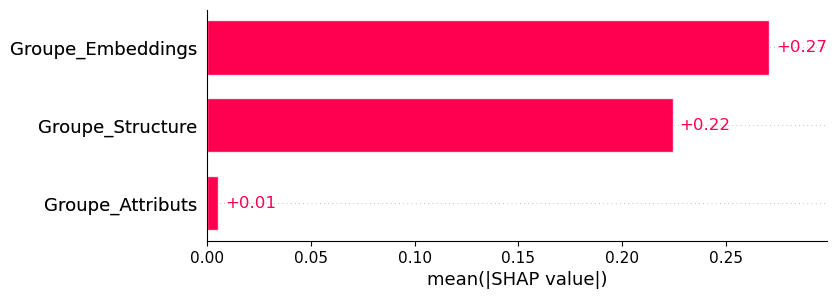


--- SHAP Bar Plot (Absolute) ---


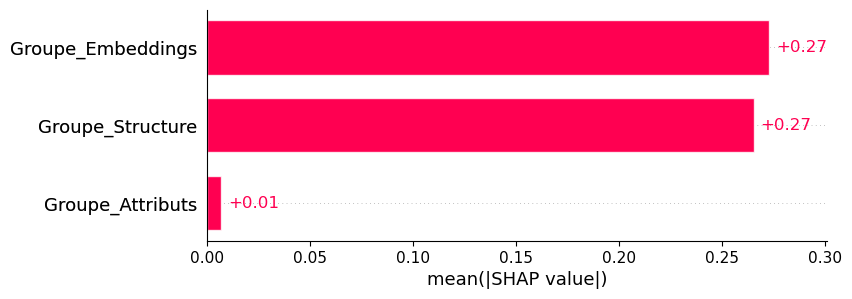


--- SHAP Custom Analysis ---


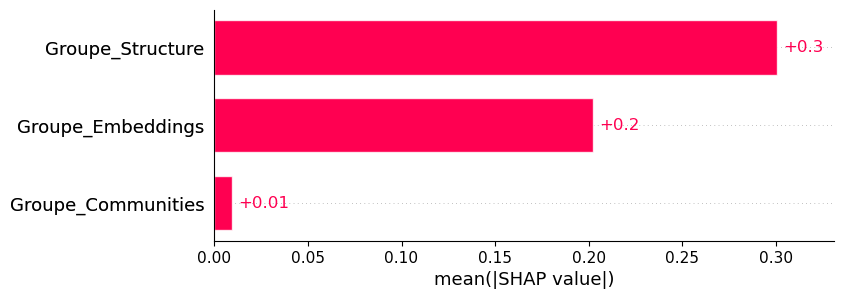


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.1554
Groupe_Attributs          | 0.2782
Groupe_Embeddings         | 0.0129


{'G_name': 'Airports',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Attributs': ['community_u',
   'community_v',
   'same_community',
   'infomap_u',
   'infomap_v',
   'same_infomap'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.15536371, 0.27823748, 0.01293887]),
 'shap_explanation_grouped': .values =
 array([[-0.20756933,  0.00253188, -0.22032932],
        [-0.20171691,  0.00532797, -0.22897594],
        [ 0.21343257, -0.00044824,  0.36124702],
        ...,
        [ 0.33796088, -0.00645035,  0.24276976],
        [-0.23479444,  0.00211415, -0.19269122],
        [ 0.19165171, -0.00063431,  0.38319667]])
 
 .base_values =
 array([0.42557451, 0.42557451, 0.42557451, ..., 0.42557451, 0.42557451,
        0.42557451]),
 'shap_explanation_abs': .val

In [4]:
a = gp.evaluate(G_name = "Airports", display=True)